In [ ]:
!pip install -q kaggle


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bhuvan2018","key":"42216687815df446ff9ce3d094a00791"}'}

In [ ]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download -d emrehakanerdemir/face-deblurring-dataset-using-celeba

Dataset URL: https://www.kaggle.com/datasets/emrehakanerdemir/face-deblurring-dataset-using-celeba
License(s): MIT
 99% 2.16G/2.18G [00:19<00:00, 236MB/s]
100% 2.18G/2.18G [00:19<00:00, 118MB/s]


In [ ]:
!unzip face-deblurring-dataset-using-celeba.zip

Streaming output truncated to the last 5000 lines.
  inflating: output/val/image_78227.jpg  
  inflating: output/val/image_78228.jpg  
  inflating: output/val/image_78229.jpg  
  inflating: output/val/image_7823.jpg  
  inflating: output/val/image_78230.jpg  
  inflating: output/val/image_78231.jpg  
  inflating: output/val/image_78232.jpg  
  inflating: output/val/image_78233.jpg  
  inflating: output/val/image_78234.jpg  
  inflating: output/val/image_78235.jpg  
  inflating: output/val/image_78236.jpg  
  inflating: output/val/image_78237.jpg  
  inflating: output/val/image_78238.jpg  
  inflating: output/val/image_78239.jpg  
  inflating: output/val/image_7824.jpg  
  inflating: output/val/image_78240.jpg  
  inflating: output/val/image_78241.jpg  
  inflating: output/val/image_78242.jpg  
  inflating: output/val/image_78243.jpg  
  inflating: output/val/image_78244.jpg  
  inflating: output/val/image_78245.jpg  
  inflating: output/val/image_78246.jpg  
  inflating: output/val/ima

In [ ]:
!pip install scikit-image
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Enhanced dataset structure handling
import os
dataset_base = '/content/face-deblurring-dataset-using-celeba'
input_base = os.path.join(dataset_base, 'input')
output_base = os.path.join(dataset_base, 'output')

IMG_SIZE = (128, 128)
SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def is_image_file(filename):
    return any(filename.lower().endswith(ext) for ext in SUPPORTED_EXTENSIONS)

def explore_dataset_structure():
    splits = ['train', 'val', 'test', 'ztest']

    for split in splits:
        input_path = os.path.join(input_base, split)
        output_path = os.path.join(output_base, split)

        if os.path.exists(input_path) and os.path.exists(output_path):
            input_files = [f for f in os.listdir(input_path) if is_image_file(f)]
            output_files = [f for f in os.listdir(output_path) if is_image_file(f)]

            print(f"📂 {split.upper()}:")
            print(f"   Input images: {len(input_files)}")
            print(f"   Output images: {len(output_files)}")
            print(f"   Match: {'✅' if len(input_files) == len(output_files) else '❌'}")
        else:
            print(f"❌ {split.upper()}: Path doesn't exist")

explore_dataset_structure()

📂 TRAIN:
   Input images: 154320
   Output images: 154320
   Match: ✅
📂 VAL:
   Input images: 19290
   Output images: 19290
   Match: ✅
📂 TEST:
   Input images: 19290
   Output images: 19290
   Match: ✅
📂 ZTEST:
   Input images: 100
   Output images: 100
   Match: ✅


In [ ]:
from PIL import Image
import numpy as np
import os

def load_image_pairs(input_folder, output_folder, split, size=(128, 128), limit=None):
    input_path = os.path.join(input_folder, split)
    output_path = os.path.join(output_folder, split)

    if not os.path.exists(input_path) or not os.path.exists(output_path):
        return np.array([]), np.array([])

    files = sorted(list(set(os.listdir(input_path)) & set(os.listdir(output_path))))
    if limit: files = files[:limit]

    X, Y = [], []
    for file in files:
        try:
            in_img = Image.open(os.path.join(input_path, file)).convert("RGB").resize(size)
            out_img = Image.open(os.path.join(output_path, file)).convert("RGB").resize(size)
            X.append(np.asarray(in_img, dtype=np.float32) / 255.0)
            Y.append(np.asarray(out_img, dtype=np.float32) / 255.0)
        except: continue

    print(f"{split}: {len(X)} pairs")
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


def load_dataset(dataset_base, img_size=(128, 128), train_limit=10000, val_limit=2000, test_limit=1000):
    input_base = os.path.join(dataset_base, 'input')
    output_base = os.path.join(dataset_base, 'output')

    X_train, y_train = load_image_pairs(input_base, output_base, 'train', img_size, train_limit)
    X_val, y_val = load_image_pairs(input_base, output_base, 'val', img_size, val_limit)
    X_test, y_test = load_image_pairs(input_base, output_base, 'test', img_size, test_limit)

    print(f"Dataset: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

dataset_base = '/content/face-deblurring-dataset-using-celeba'
(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_dataset(
    dataset_base,
    img_size=(128, 128),
    train_limit=8000,
    val_limit=2000,
    test_limit=1000
)

train: 8000 pairs
val: 2000 pairs
test: 1000 pairs
Dataset: Train=8000, Val=2000, Test=1000


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import tensorflow as tf
import tensorflow.keras.backend as K

# ---------------------
# CBAM Block
# ---------------------
def cbam_block(x, ratio=8):
    channel = x.shape[-1]

    # Channel Attention
    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_one = Dense(channel // ratio, activation='relu', use_bias=False)
    shared_dense_two = Dense(channel, use_bias=False)

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = Activation('sigmoid')(Add()([avg_out, max_out]))
    channel_attention = Reshape((1, 1, channel))(channel_attention)
    x = Multiply()([x, channel_attention])

    # Spatial Attention
    avg_pool_spatial = Lambda(lambda x: K.mean(x, axis=3, keepdims=True))(x)
    max_pool_spatial = Lambda(lambda x: K.max(x, axis=3, keepdims=True))(x)
    concat = Concatenate(axis=3)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = Conv2D(1, kernel_size=7, strides=1, padding='same', activation='sigmoid')(concat)
    x = Multiply()([x, spatial_attention])

    return x

# ---------------------
# Attention Block
# ---------------------
def attention_block(x, g, inter_channels):
    theta_x = Conv2D(inter_channels, 1, padding='same')(x)
    phi_g = Conv2D(inter_channels, 1, padding='same')(g)
    add = Activation('relu')(Add()([theta_x, phi_g]))
    psi = Conv2D(1, 1, padding='same', activation='sigmoid')(add)
    return Multiply()([x, psi])

# ---------------------
# Residual Block with CBAM
# ---------------------
def residual_block(x, filters):
    shortcut = x
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut])
    x = LeakyReLU(0.1)(x)
    x = cbam_block(x)  # Apply CBAM after residual
    return x

# ---------------------
# Perceptual + Pixel Loss
# ---------------------
vgg_model = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
vgg_model.trainable = False
feature_extractor = Model(inputs=vgg_model.input, outputs=vgg_model.get_layer('block3_conv3').output)

def perceptual_loss(y_true, y_pred):
    y_true = preprocess_input(y_true * 255.0)
    y_pred = preprocess_input(y_pred * 255.0)
    f_true = feature_extractor(y_true)
    f_pred = feature_extractor(y_pred)
    perceptual = tf.reduce_mean(tf.square(f_true - f_pred))
    pixel = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * perceptual + 0.4 * pixel

# ---------------------
# U-Net with Residual + Attention + CBAM
# ---------------------
def create_unet(input_shape=(128, 128, 3)):
    inputs = Input(shape=input_shape)

    # Encoder
    conv1 = residual_block(Conv2D(64, 3, padding='same')(inputs), 64)
    pool1 = MaxPooling2D(2)(conv1)

    conv2 = residual_block(Conv2D(128, 3, padding='same')(pool1), 128)
    pool2 = MaxPooling2D(2)(conv2)

    conv3 = residual_block(Conv2D(256, 3, padding='same')(pool2), 256)
    pool3 = MaxPooling2D(2)(conv3)

    # Bottleneck
    bottleneck = Conv2D(512, 3, padding='same')(pool3)
    bottleneck = BatchNormalization()(bottleneck)
    bottleneck = LeakyReLU(0.1)(bottleneck)
    bottleneck = cbam_block(bottleneck)

    # Decoder
    up1 = Conv2DTranspose(256, 2, strides=2, padding='same')(bottleneck)
    att1 = attention_block(conv3, up1, 128)
    merge1 = Concatenate()([att1, up1])
    conv4 = residual_block(Conv2D(256, 3, padding='same')(merge1), 256)

    up2 = Conv2DTranspose(128, 2, strides=2, padding='same')(conv4)
    att2 = attention_block(conv2, up2, 64)
    merge2 = Concatenate()([att2, up2])
    conv5 = residual_block(Conv2D(128, 3, padding='same')(merge2), 128)

    up3 = Conv2DTranspose(64, 2, strides=2, padding='same')(conv5)
    att3 = attention_block(conv1, up3, 32)
    merge3 = Concatenate()([att3, up3])
    conv6 = residual_block(Conv2D(64, 3, padding='same')(merge3), 64)

    outputs = Conv2D(3, 1, activation='sigmoid', padding='same')(conv6)

    return Model(inputs, outputs)

# ---------------------
# Compile the model
# ---------------------
print("✅ Building Residual + Attention + CBAM U-Net...")
autoencoder = create_unet()
autoencoder.compile(optimizer=Adam(1e-4), loss=perceptual_loss, metrics=['mae'])
print(f"🔢 Total Params: {autoencoder.count_params():,}")
autoencoder.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Building Residual + Attention + CBAM U-Net...
🔢 Total Params: 7,091,995


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ leaky_re_lu_1[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ leaky_re_lu_1[0]… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        512 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        512 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64)        │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64)        │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128,  │          0 │ leaky_re_lu_1[0]… │
│                     │ 64)               │            │ reshape[0][0]   

 Total params: 7,091,995 (27.05 MB)

 Trainable params: 7,087,387 (27.04 MB)

 Non-trainable params: 4,608 (18.00 KB)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 238s 370ms/step - loss: 93327.9297 - mae: 0.1043 - pixel_accuracy: 0.3383 - psnr_metric: 18.4141 - ssim_metric: 0.4929 - val_loss: 78060.1016 - val_mae: 0.0981 - val_pixel_accuracy: 0.2810 - val_psnr_metric: 18.6812 - val_ssim_metric: 0.5074 - learning_rate: 0.0010
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 228s 372ms/step - loss: 69071.6875 - mae: 0.0745 - pixel_accuracy: 0.4323 - psnr_metric: 20.4804 - ssim_metric: 0.5443 - val_loss: 63002.4492 - val_mae: 0.0710 - val_pixel_accuracy: 0.4558 - val_psnr_metric: 20.5867 - val_ssim_metric: 0.5697 - learning_rate: 0.0010
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 198s 365ms/step - loss: 58118.8203 - mae: 0.0683 - pixel_accuracy: 0.4714 - psnr_metric: 21.1548 - ssim_metric: 0.5859 - val_loss: 54695.4492 - val_mae: 0.0623 - val_pixel_accuracy: 0.5234 - val_psnr_metric: 21.7150 - val_ssim_metric: 0.6244 - learning_rate: 0.0010
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 206s 372ms/step - loss: 51787.4102 - mae: 

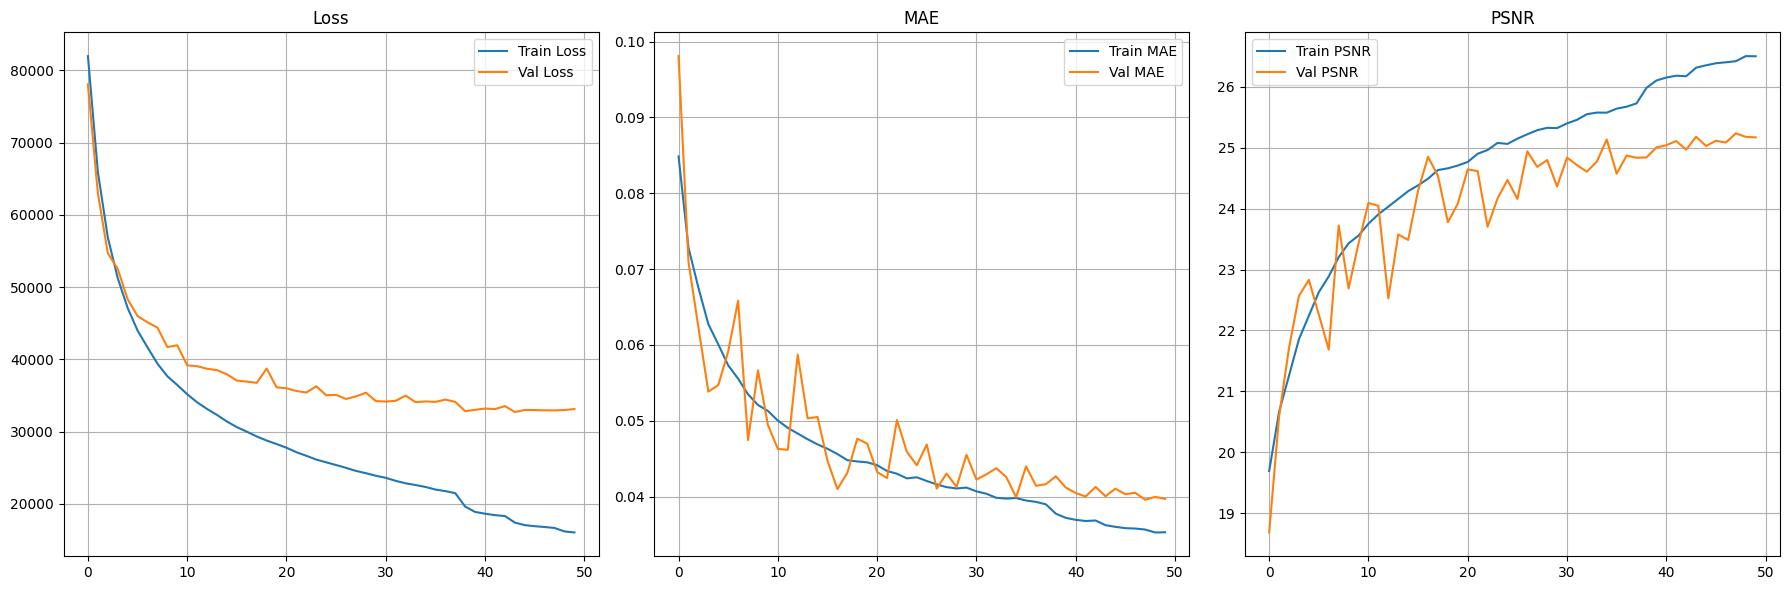

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import gc

# ========== 🧠 Enable GPU memory growth ==========
def optimize_memory():
    gc.collect()
    try:
        gpus = tf.config.experimental.list_physical_devices('GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

# ========== 🔍 Perceptual Loss (VGG Block3) ==========
def get_vgg16_features():
    vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    vgg.trainable = False
    return Model(inputs=vgg.input, outputs=vgg.get_layer("block3_conv3").output)

vgg_model = get_vgg16_features()

def perceptual_loss(y_true, y_pred):
    y_true = preprocess_input(y_true * 255.0)
    y_pred = preprocess_input(y_pred * 255.0)

    f_true = vgg_model(y_true)
    f_pred = vgg_model(y_pred)

    perceptual = tf.reduce_mean(tf.square(f_true - f_pred))
    pixel_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * perceptual + 0.4 * pixel_loss

# ========== 📊 Additional Metrics ==========
def pixel_accuracy(y_true, y_pred):
    return tf.reduce_mean(tf.cast(tf.less_equal(tf.abs(y_true - y_pred), 0.05), tf.float32))

def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# ========== 📦 Resize Utility ==========
def resize_data(X, size=(128, 128)):
    return tf.image.resize(X, size)

# ========== 🏋️‍♂️ Training Function ==========
def train_model(autoencoder, X_train, y_train, X_val, y_val, batch_size=16, epochs=30):
    optimize_memory()

    X_train = resize_data(X_train)
    y_train = resize_data(y_train)
    X_val = resize_data(X_val)
    y_val = resize_data(y_val)

    autoencoder.compile(
        optimizer='adam',
        loss=perceptual_loss,
        metrics=['mae', pixel_accuracy, psnr_metric, ssim_metric]
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
    ]

    history = autoencoder.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        shuffle=True,
        verbose=1
    )

    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\n✅ Best Epoch: {best_epoch + 1}")
    print(f"📉 Best Val Loss: {history.history['val_loss'][best_epoch]:.4f}")

    return history

# ========== 📈 Plot History ==========
def plot_history(history):
    plt.figure(figsize=(18, 6))

    # 1. Loss
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # 2. MAE
    plt.subplot(1, 3, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title("MAE")
    plt.legend()
    plt.grid(True)

    # 3. PSNR
    plt.subplot(1, 3, 3)
    plt.plot(history.history['psnr_metric'], label='Train PSNR')
    plt.plot(history.history['val_psnr_metric'], label='Val PSNR')
    plt.title("PSNR")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Example Training
history = train_model(autoencoder, X_train, y_train, X_val, y_val, batch_size=16, epochs=50)
plot_history(history)

Evaluating 20 samples...


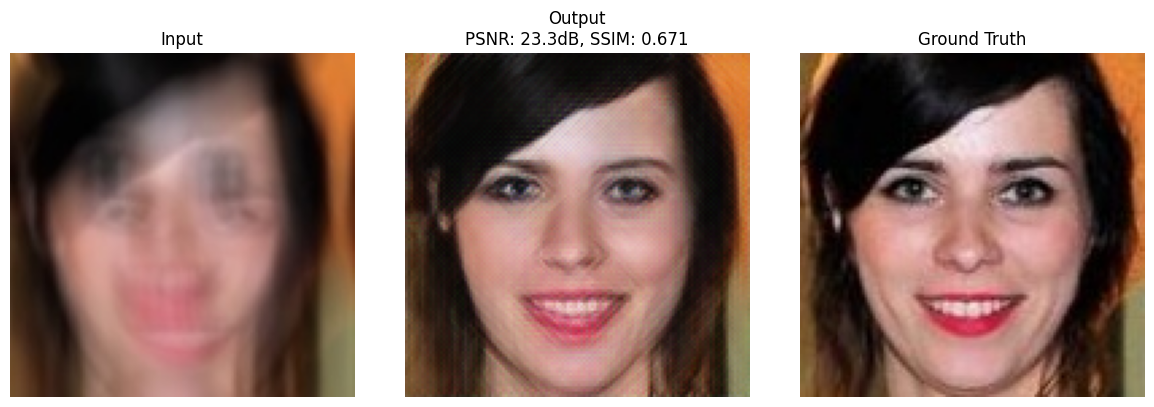

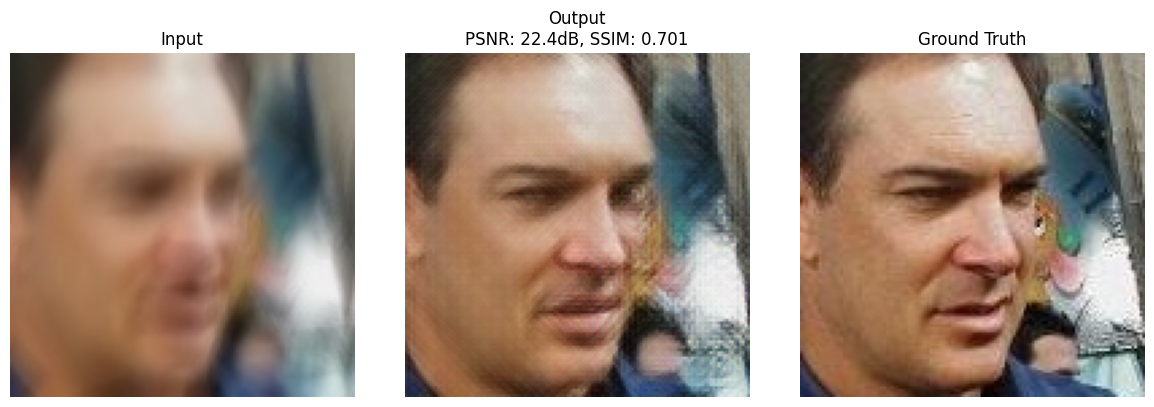

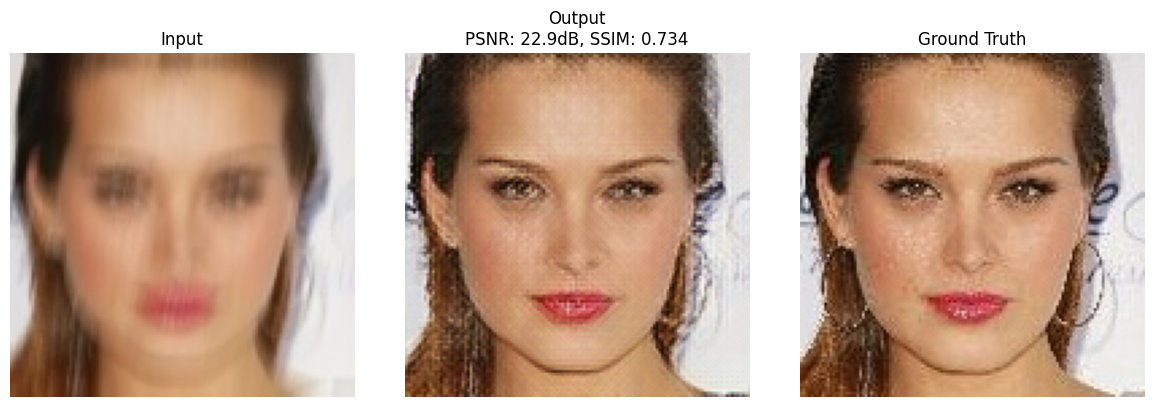


Results:
Average PSNR: 24.37 ± 2.64 dB
Average SSIM: 0.7039 ± 0.1125
⚠ Moderate quality


In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def evaluate_model(model, x_val, y_val, num_samples=5):
    psnr_scores, ssim_scores = [], []

    # Resize validation data to match model input size
    x_val_resized = tf.image.resize(x_val, (128, 128))
    y_val_resized = tf.image.resize(y_val, (128, 128))

    print(f"Evaluating {num_samples} samples...")

    for i in range(num_samples):
        input_img = x_val_resized[i:i+1]
        output_img = model.predict(input_img, verbose=0)[0]
        ground_truth = y_val_resized[i]

        # Ensure pixel values are between 0 and 1
        output_img = np.clip(output_img, 0, 1)
        ground_truth = np.clip(ground_truth, 0, 1)

        # Convert to uint8 for PSNR and SSIM
        output_uint8 = (output_img * 255).astype(np.uint8)
        gt_uint8 = (ground_truth * 255).astype(np.uint8)

        # Calculate PSNR and SSIM
        psnr_val = psnr(gt_uint8, output_uint8, data_range=255)
        ssim_val = ssim(gt_uint8, output_uint8, channel_axis=-1, data_range=255)

        psnr_scores.append(psnr_val)
        ssim_scores.append(ssim_val)

        if i < 3:
            fig, axs = plt.subplots(1, 3, figsize=(12, 4))
            axs[0].imshow(x_val[i])  # Original size for visual comparison
            axs[0].set_title("Input")
            axs[0].axis("off")

            axs[1].imshow(output_img)
            axs[1].set_title(f"Output\nPSNR: {psnr_val:.1f}dB, SSIM: {ssim_val:.3f}")
            axs[1].axis("off")

            axs[2].imshow(y_val[i])  # Original size for visual comparison
            axs[2].set_title("Ground Truth")
            axs[2].axis("off")

            plt.tight_layout()
            plt.show()

    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)

    print(f"\nResults:")
    print(f"Average PSNR: {avg_psnr:.2f} ± {np.std(psnr_scores):.2f} dB")
    print(f"Average SSIM: {avg_ssim:.4f} ± {np.std(ssim_scores):.4f}")

    if avg_psnr > 25:
        print("✅ Good quality reconstruction")
    elif avg_psnr > 20:
        print("⚠ Moderate quality")
    else:
        print("❌ Poor quality - needs improvement")

    return {'psnr': avg_psnr, 'ssim': avg_ssim, 'psnr_scores': psnr_scores, 'ssim_scores': ssim_scores}

# Run the evaluation
results = evaluate_model(autoencoder, X_val, y_val, num_samples=20)


In [ ]:
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import tensorflow as tf

def calculate_psnr(y_true, y_pred):
    """
    Peak Signal-to-Noise Ratio (PSNR)
    Higher is better (typically 20-40 dB)
    """
    return peak_signal_noise_ratio(y_true, y_pred, data_range=1.0)

def calculate_ssim(y_true, y_pred):
    """
    Structural Similarity Index (SSIM)
    Range: -1 to 1, where 1 is perfect similarity
    """
    return structural_similarity(y_true, y_pred, multichannel=True, channel_axis=-1, data_range=1.0)

def calculate_mse(y_true, y_pred):
    """
    Mean Squared Error (MSE)
    Lower is better
    """
    return np.mean((y_true - y_pred) ** 2)

def calculate_mae(y_true, y_pred):
    """
    Mean Absolute Error (MAE)
    Lower is better
    """
    return np.mean(np.abs(y_true - y_pred))

def evaluate_model_performance(model, X_test, y_test, num_samples=100):
    """
    Comprehensive evaluation of denoising autoencoder
    """
    # Predict on test set
    print("🔄 Making predictions...")
    predictions = model.predict(X_test[:num_samples])

    # Initialize metrics
    psnr_scores = []
    ssim_scores = []
    mse_scores = []
    mae_scores = []

    print(f"📊 Evaluating {num_samples} test samples...")

    for i in range(num_samples):
        true_img = y_test[i]
        pred_img = predictions[i]

        # Calculate metrics
        psnr = calculate_psnr(true_img, pred_img)
        ssim = calculate_ssim(true_img, pred_img)
        mse = calculate_mse(true_img, pred_img)
        mae = calculate_mae(true_img, pred_img)

        psnr_scores.append(psnr)
        ssim_scores.append(ssim)
        mse_scores.append(mse)
        mae_scores.append(mae)

        if (i + 1) % 20 == 0:
            print(f"   Processed {i + 1}/{num_samples} samples...")

    # Calculate average metrics
    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)
    avg_mse = np.mean(mse_scores)
    avg_mae = np.mean(mae_scores)

    print(f"\n✅ EVALUATION RESULTS:")
    print(f"   📈 Average PSNR: {avg_psnr:.2f} dB")
    print(f"   📈 Average SSIM: {avg_ssim:.4f}")
    print(f"   📉 Average MSE: {avg_mse:.6f}")
    print(f"   📉 Average MAE: {avg_mae:.6f}")

    # Interpretation
    print(f"\n🎯 PERFORMANCE INTERPRETATION:")
    if avg_psnr > 25:
        print(f"   PSNR: GOOD (>{avg_psnr:.1f} dB)")
    elif avg_psnr > 20:
        print(f"   PSNR: FAIR ({avg_psnr:.1f} dB)")
    else:
        print(f"   PSNR: NEEDS IMPROVEMENT ({avg_psnr:.1f} dB)")

    if avg_ssim > 0.8:
        print(f"   SSIM: EXCELLENT ({avg_ssim:.3f})")
    elif avg_ssim > 0.6:
        print(f"   SSIM: GOOD ({avg_ssim:.3f})")
    elif avg_ssim > 0.4:
        print(f"   SSIM: FAIR ({avg_ssim:.3f})")
    else:
        print(f"   SSIM: NEEDS IMPROVEMENT ({avg_ssim:.3f})")

    return {
        'psnr': avg_psnr,
        'ssim': avg_ssim,
        'mse': avg_mse,
        'mae': avg_mae,
        'individual_psnr': psnr_scores,
        'individual_ssim': ssim_scores
    }

def compare_images_visually(model, X_test, y_test, num_images=5):
    """
    Visual comparison of results
    """
    import matplotlib.pyplot as plt

    predictions = model.predict(X_test[:num_images])

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4*num_images))

    for i in range(num_images):
        # Blurred input
        axes[i, 0].imshow(X_test[i])
        axes[i, 0].set_title(f'Blurred Input {i+1}')
        axes[i, 0].axis('off')

        # Model prediction
        axes[i, 1].imshow(predictions[i])
        axes[i, 1].set_title(f'Model Output {i+1}')
        axes[i, 1].axis('off')

        # Ground truth
        axes[i, 2].imshow(y_test[i])
        axes[i, 2].set_title(f'Ground Truth {i+1}')
        axes[i, 2].axis('off')

        # Calculate metrics for this image
        psnr = calculate_psnr(y_test[i], predictions[i])
        ssim = calculate_ssim(y_test[i], predictions[i])

        axes[i, 1].text(0.5, -0.1, f'PSNR: {psnr:.2f} dB\nSSIM: {ssim:.3f}',
                       transform=axes[i, 1].transAxes, ha='center')

    plt.tight_layout()
    plt.show()

# Usage example:
# After training your model, evaluate it like this:
results = evaluate_model_performance(autoencoder,X_test,y_test)

🔄 Making predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
📊 Evaluating 100 test samples...
   Processed 20/100 samples...
   Processed 40/100 samples...
   Processed 60/100 samples...
   Processed 80/100 samples...
   Processed 100/100 samples...

✅ EVALUATION RESULTS:
   📈 Average PSNR: 25.14 dB
   📈 Average SSIM: 0.7478
   📉 Average MSE: 0.003587
   📉 Average MAE: 0.039857

🎯 PERFORMANCE INTERPRETATION:
   PSNR: GOOD (>25.1 dB)
   SSIM: GOOD (0.748)


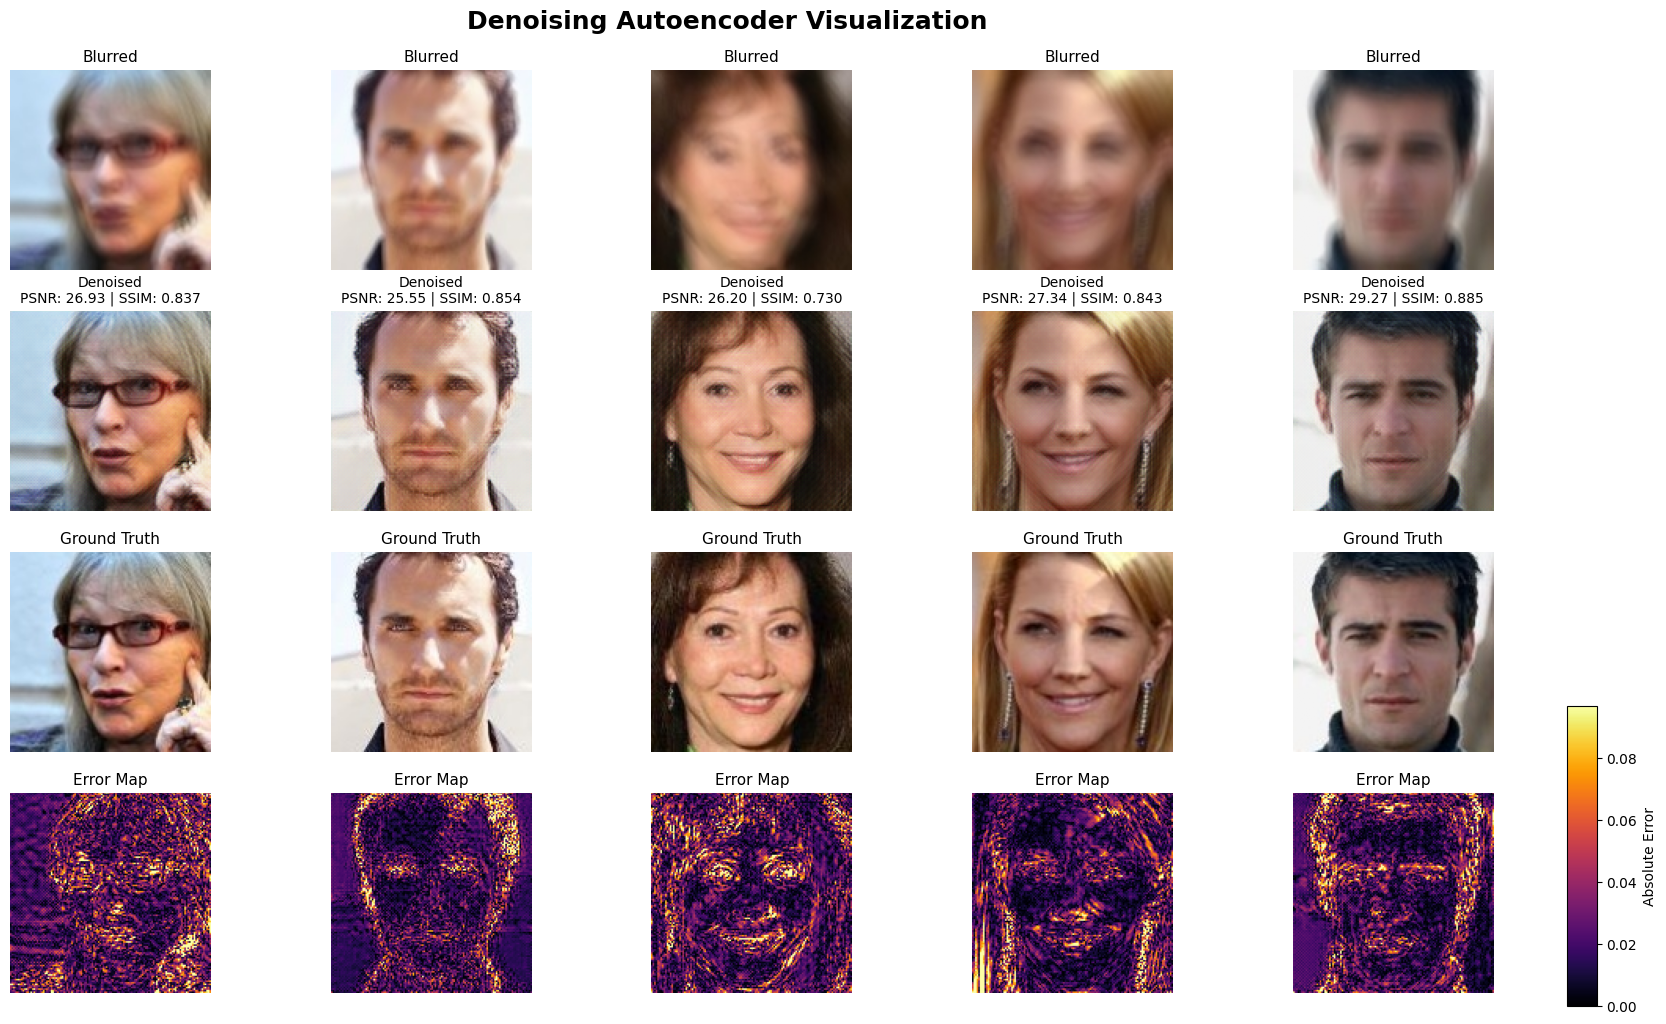

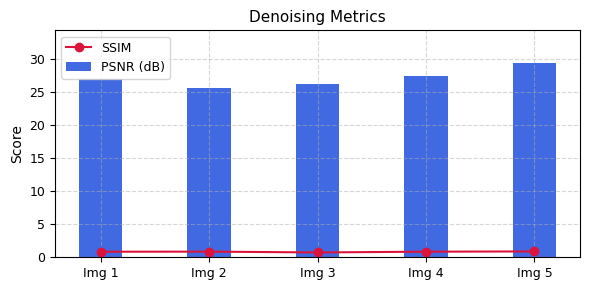

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
def visualize_denoising_results(model, x_val, y_val, num_images=5):
    indices = np.random.randint(0, len(x_val), size=num_images)
    fig, axs = plt.subplots(4, num_images, figsize=(4 * num_images, 12))
    fig.suptitle("Denoising Autoencoder Visualization", fontsize=18, fontweight='bold', y=0.93)
    psnr_values = []
    ssim_values = []
    for i, idx in enumerate(indices):
        blurred = x_val[idx]
        ground_truth = y_val[idx]
        denoised = model.predict(blurred.reshape(1, 128,128, 3), verbose=0)[0]
        # Grayscale for metrics & error map
        gt_gray = np.mean(ground_truth, axis=-1)
        denoised_gray = np.mean(denoised, axis=-1)
        psnr_val = psnr(gt_gray, denoised_gray, data_range=1.0)
        ssim_val = ssim(gt_gray, denoised_gray, data_range=1.0)
        psnr_values.append(psnr_val)
        ssim_values.append(ssim_val)
        # Row 1: Blurred
        axs[0, i].imshow(blurred)
        axs[0, i].set_title("Blurred", fontsize=11)
        axs[0, i].axis('off')
        # Row 2: Denoised + Metrics
        axs[1, i].imshow(np.clip(denoised, 0, 1))
        axs[1, i].set_title(f"Denoised\nPSNR: {psnr_val:.2f} | SSIM: {ssim_val:.3f}", fontsize=10)
        axs[1, i].axis('off')
        # Row 3: Ground Truth
        axs[2, i].imshow(ground_truth)
        axs[2, i].set_title("Ground Truth", fontsize=11)
        axs[2, i].axis('off')
        # Row 4: Error Map
        error_map = np.abs(gt_gray - denoised_gray)
        vmax_val = np.percentile(error_map, 98)
        im = axs[3, i].imshow(error_map, cmap='inferno', vmin=0, vmax=vmax_val)
        axs[3, i].set_title("Error Map", fontsize=11)
        axs[3, i].axis('off')
    # Colorbar
    cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.25])
    fig.colorbar(im, cax=cbar_ax, label='Absolute Error')
    # Row labels
    row_labels = ["Input", "Denoised", "Ground Truth", "Error Map"]
    for ax, row_label in zip(axs[:, 0], row_labels):
        ax.set_ylabel(row_label, rotation=90, fontsize=13, labelpad=10)
    #plt.tight_layout(rect=[0, 0, 0.9, 0.92])
    plt.show()
        # ---------- Compact Data Visualization Chart ----------
    fig2, ax2 = plt.subplots(figsize=(6, 3))  # Smaller size
    x_labels = [f"Img {i+1}" for i in range(num_images)]
    bar_width = 0.4
    ax2.bar(x_labels, psnr_values, width=bar_width, label='PSNR (dB)', color='royalblue')
    ax2.plot(x_labels, ssim_values, marker='o', color='crimson', label='SSIM', linewidth=1.5)
    ax2.set_title("Denoising Metrics", fontsize=11)
    ax2.set_ylabel("Score", fontsize=10)
    ax2.set_ylim(0, max(max(psnr_values) + 5, 1.0))
    ax2.tick_params(axis='x', labelsize=9)
    ax2.tick_params(axis='y', labelsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

visualize_denoising_results(autoencoder, X_train, y_train,num_images=5)

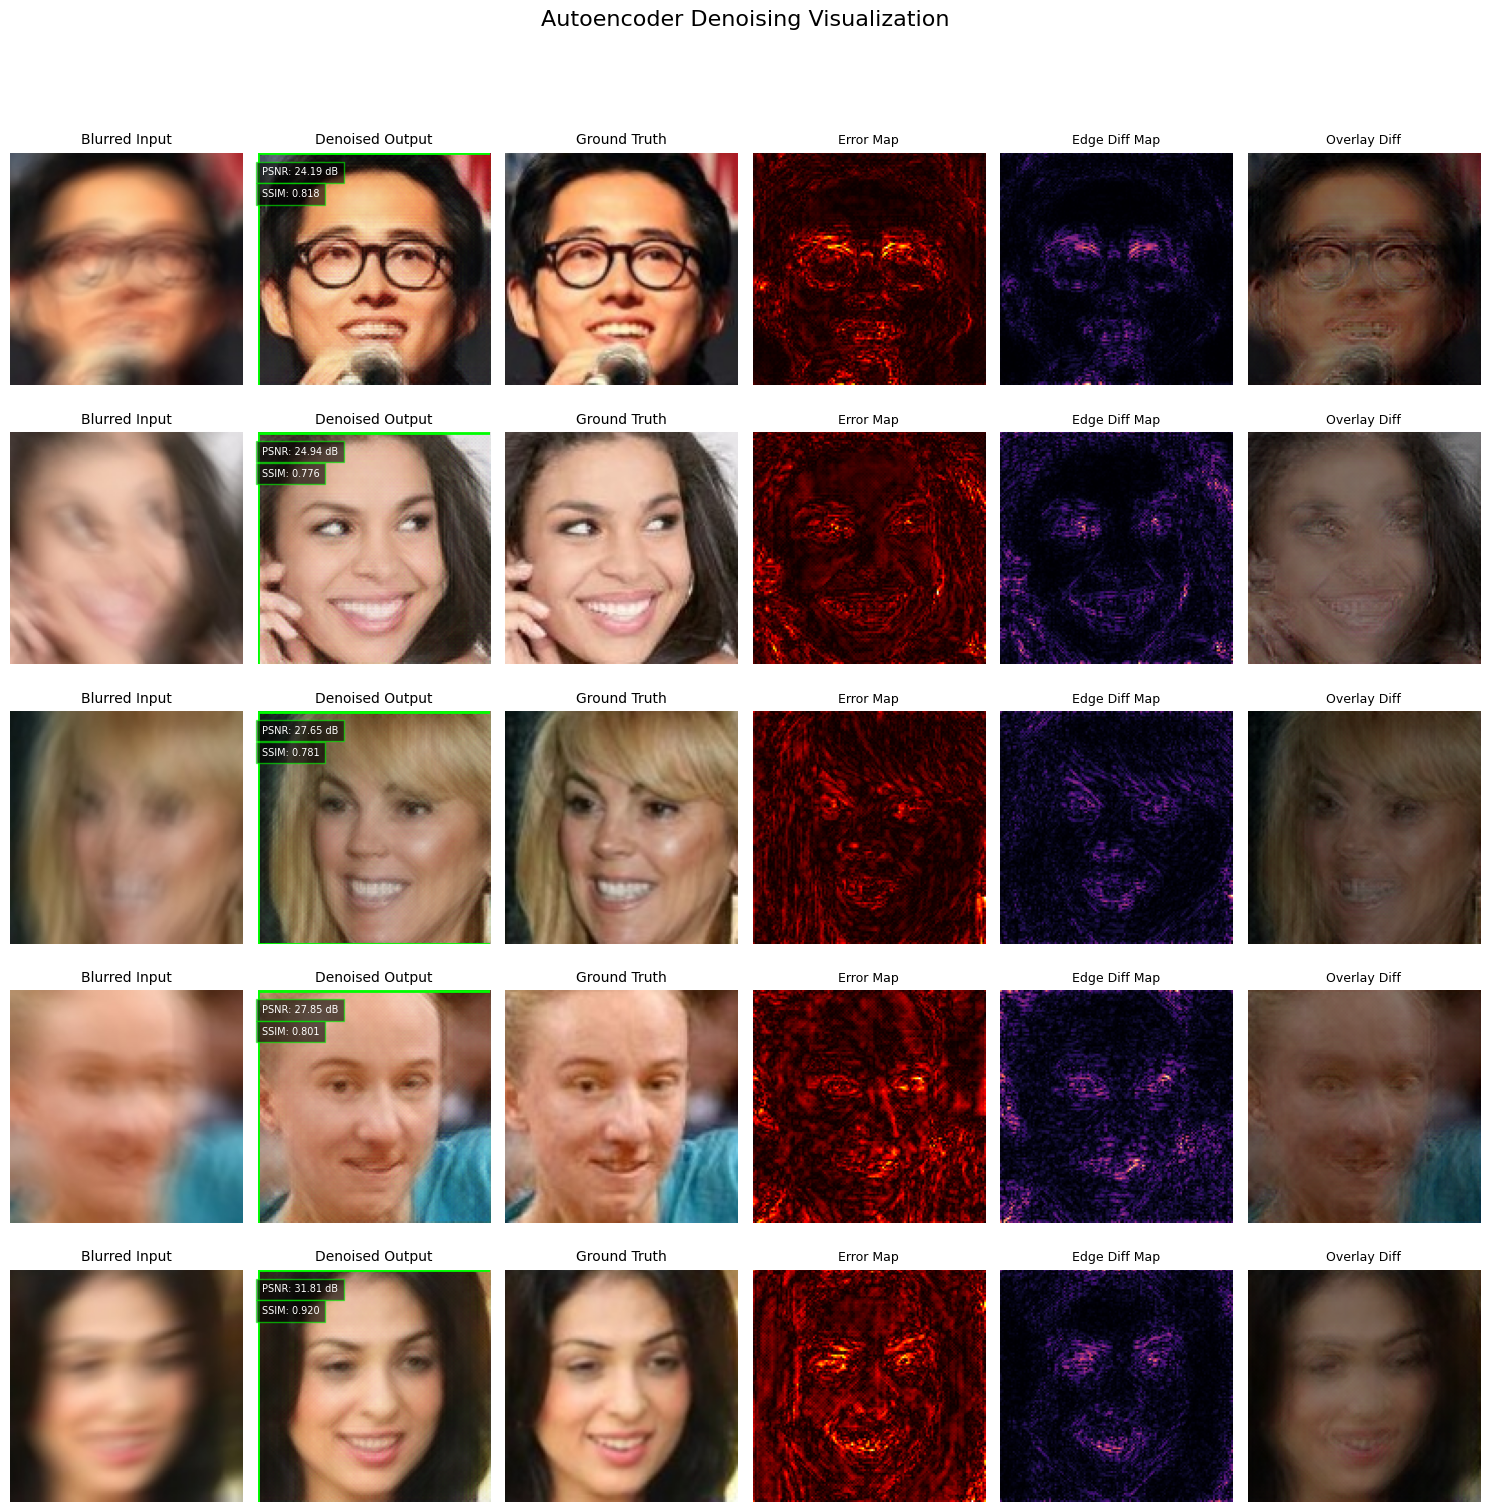

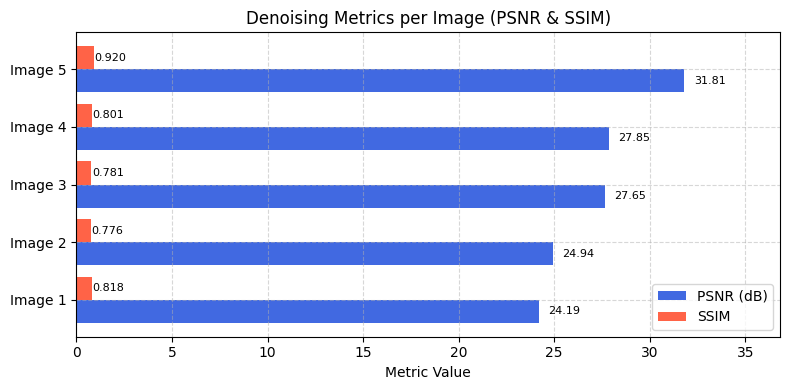

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from matplotlib.patches import Rectangle

# Number of images
num_images = 5
random_images = np.random.randint(0, X_train.shape[0], size=num_images)

# Store metrics for visualization
psnr_values = []
ssim_values = []

plt.figure(figsize=(15, num_images * 3))  # Wider layout for comparisons

for i, idx in enumerate(random_images):
    blurred = X_train[idx]
    ground_truth = y_train[idx]
    denoised = autoencoder.predict(blurred.reshape(1, 128, 128, 3), verbose=0)[0]

    # Convert to grayscale for metric calculations
    gt_gray = np.mean(ground_truth, axis=-1)
    denoised_gray = np.mean(denoised, axis=-1)

    # Metrics
    psnr_val = psnr(gt_gray, denoised_gray, data_range=1.0)
    ssim_val = ssim(gt_gray, denoised_gray, data_range=1.0)
    psnr_values.append(psnr_val)
    ssim_values.append(ssim_val)

    # --- Row 1: Image Comparison ---
    for j, (title, image) in enumerate([
        ("Blurred Input", blurred),
        ("Denoised Output", denoised),
        ("Ground Truth", ground_truth)
    ]):
        ax = plt.subplot(num_images, 6, i * 6 + j + 1)
        plt.imshow(image)
        plt.title(title, fontsize=10)
        plt.axis('off')
        if title == "Denoised Output":
            ax.add_patch(Rectangle((0, 0), 128, 128, linewidth=2, edgecolor='lime', facecolor='none'))
            ax.text(2, 12, f"PSNR: {psnr_val:.2f} dB", color='white', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.6, edgecolor='lime'))
            ax.text(2, 24, f"SSIM: {ssim_val:.3f}", color='white', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.6, edgecolor='lime'))

    # --- Row 2: Error & Difference Maps ---
    diff_map = np.abs(gt_gray - denoised_gray)
    edge_map = np.abs(np.gradient(gt_gray)[0] - np.gradient(denoised_gray)[0])

    for j, (title, image, cmap) in enumerate([
        ("Error Map", diff_map, 'hot'),
        ("Edge Diff Map", edge_map, 'magma'),
        ("Overlay Diff", 0.5 * blurred + 0.5 * (ground_truth - denoised), None)
    ]):
        ax = plt.subplot(num_images, 6, i * 6 + j + 4)
        if cmap:
            im = plt.imshow(image, cmap=cmap)
        else:
            im = plt.imshow(np.clip(image, 0, 1))
        plt.title(title, fontsize=9)
        plt.axis('off')

plt.tight_layout()
plt.suptitle("Autoencoder Denoising Visualization", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.94)
plt.savefig("enhanced_denoising_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
y_labels = [f"Image {i+1}" for i in range(num_images)]
y_pos = np.arange(num_images)

# Plot bars for PSNR and SSIM
bar1 = ax.barh(y_pos - 0.2, psnr_values, height=0.4, color='royalblue', label='PSNR (dB)')
bar2 = ax.barh(y_pos + 0.2, ssim_values, height=0.4, color='tomato', label='SSIM')

# Add text labels
for bar in bar1:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2f}", va='center', fontsize=8)
for bar in bar2:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}", va='center', fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Metric Value")
ax.set_title("Denoising Metrics per Image (PSNR & SSIM)")
ax.set_xlim(0, max(max(psnr_values) + 5, 1.0))
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Save the model to a file
autoencoder.save('autoencoder_perceptual_loss.h5')
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
autoencoder.export('autoencoder_model')

Saved artifact at 'autoencoder_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_19')
Output Type:
  TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None)
Captures:
  132877810203152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877810204304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877810203728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877810203920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877809763344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877809762384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877810204496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877809762576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877809764880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132877809765456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  